# Bayesian optimization of PHASTIMATE parameters

It may be ideal in certain circumstances to systematically optimize the parameters involved in the PHASTIMATE toolbox. For instance, you may be dealing with a population known to contain a large degree of inter-individual variability in the SNR of your target frequency band. Thus, the PHASTIMATE parameters that work for one individual may not work well for another. You can optptimize the `window_edge` and `ar_order` parameters of PHASTIMATE to tailor the algorithm on an inter-individual basis.

Below we showcase how this can be done in EEGPhasePy using Bayesian optimization. If you use this algorithm please cite the BayesianOptimization library (https://github.com/bayesian-optimization/BayesianOptimization)

In [1]:
import sys
import numpy as np
import scipy.signal as signal

sys.path.append("../../..")

from EEGPhasePy.estimators import PHASTIMATE

Generate the simulated training and testing EEG data

In [2]:
fs = 2000
time_data = np.arange(0, 90, 1/fs)

training_signal_clean = np.sin(2 * np.pi * 10 * time_data)
training_signal = training_signal_clean + np.random.normal(0, 2, len(time_data))

testing_signal_clean = np.sin(2 * np.pi * 10 * time_data)
testing_signal = testing_signal_clean + np.random.normal(0, 2, len(time_data))

Define the real-time and ground-truth alpha bandpass filters. 

The real-time filter should be lower order since it will be applied to a window with fewer samples than the ground truth filter. The ground truth filter is what will be used to extract the phase for phase stats (i.e. accuracy, mean and std of phase) as well as to generate the polar histogram and trigger waveform plots

In [3]:
rt_filter = signal.firwin(120, [8, 12], fs=fs, pass_zero=False)
gt_filter = signal.firwin(300, [8, 12], fs=fs, pass_zero=False)

Next, we will instantiate PHASTIMATE. 

In [4]:
phastimate = PHASTIMATE(rt_filter, gt_filter, fs)

Now we will run the bayesian optimization algorithm using the `optimize_parameters` method with the `method` argument being set to bayesian. This method will update the `window_edge` and `ar_order` that result in the phase estimation accuracy

In [5]:
phastimate.optimize_parameters(training_signal, 'bayesian')

[PHASTIMATE Bayesian Optimization] Starting bayesian optimization....
|   iter    |  target   |   edge    | ar_order  |
-------------------------------------------------
| 1         | 0.9999873 | 41.107159 | 196.10809 |
| 2         | 0.9999519 | 58.986036 | 91.002020 |
| 3         | 0.9996534 | 13.753582 | 188.82134 |
| 4         | 0.9987292 | 8.2877372 | 39.512807 |
| 5         | 0.9993479 | 27.855736 | 180.58264 |
| 6         | 0.9995668 | 38.844486 | 19.186834 |
| 7         | 0.9993465 | 10.952812 | 191.71441 |
| 8         | 0.9994681 | 26.628747 | 88.742240 |
| 9         | 0.9999237 | 43.856908 | 165.30726 |
| 10        | 0.9997231 | 53.671867 | 132.26679 |
| 11        | 0.9998152 | 50.225067 | 27.559918 |
| 12        | 0.9997010 | 51.576894 | 194.02036 |
| 13        | 0.9996980 | 39.645297 | 105.48513 |
| 14        | 0.9996754 | 52.551350 | 51.831655 |
| 15        | 0.9999496 | 40.943205 | 196.28761 |
| 16        | 0.9999704 | 44.032569 | 194.23240 |
| 17        | 0.9997095 | 40.8

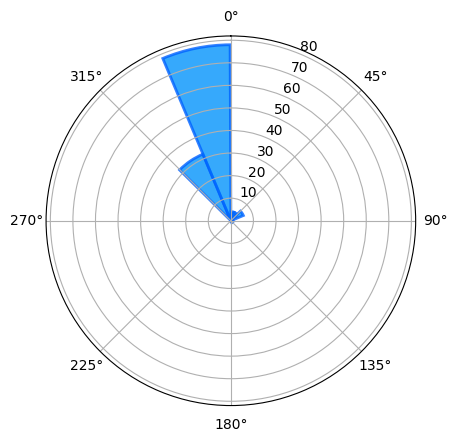

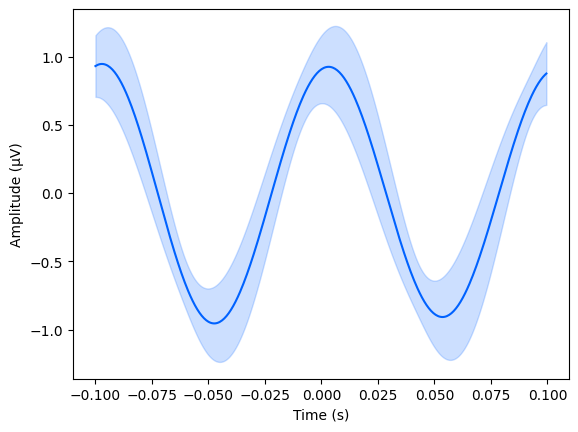

In [6]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(testing_signal):
    window = testing_signal[window_i:window_i + window_len]

    if phastimate.predict(window, 0, 15):
        triggers.append(window_i + window_len)
        
    window_i += window_step

polar_hist_fig = phastimate.polar_histogram_from_triggers(testing_signal, triggers)
waveform_fig = phastimate.plot_mean_std_waveform_from_triggers(testing_signal, triggers, tmin=0.1, tmax=0.1)